# Radar-Based Person Detection with SR250

Classification of radar CIR data for person/non-person detection using deep learning.

## Pipeline Overview

1. **Data Loading** - Load .npy files from class folders
2. **Preprocessing** - Extract range bins, declutter, filter (entire file)
3. **Windowing** - Split into 5-second windows
4. **Feature Extraction** - FFT per window
5. **Model Training** - CNN for binary classification
6. **Deployment** - TFLite conversion (weights quantized, activations optional)
7. **Embedded Export** - TFLite Micro C array (.h file)

## 1. Setup

In [1]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## 2. Configuration

In [2]:
# Radar parameters
FPS = 10
WINDOW_DURATION = 5
WINDOW_SIZE = FPS * WINDOW_DURATION
FIRST_TAPS_TO_SKIP = 6
RANGE_BINS = 20
FFT_POINTS = 128

# Preprocessing
ALPHA = 0.9
CUTOFF_FREQ = 2.0
FILTER_ORDER = 2

# Training
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.15

# Data
DATA_LINK = "https://drive.google.com/drive/folders/1VL-6UmmFMhbhLVL1UuOPTYGgWg-0aWno?usp=share_link"
DATA_DIR = "data"
CLASSES = ["person", "no_person"]

In [3]:
import gdown
import re

# Ensure gdown is installed
!pip install -q gdown

# Create data directory if it doesn't exist
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
    print(f"Created directory: {DATA_DIR}")

# Extract folder ID from DATA_LINK
match = re.search(r'id=([a-zA-Z0-9_-]+)|folders/([a-zA-Z0-9_-]+)', DATA_LINK)
folder_id = None
if match:
    if match.group(1): # Pattern with 'id=' (e.g., file links, sometimes folder links) - less reliable for folders
        folder_id = match.group(1)
    elif match.group(2): # Pattern with 'folders/' (e.g., folder links)
        folder_id = match.group(2)

if folder_id:
    print(f"Downloading Google Drive folder (ID: {folder_id}) to {DATA_DIR}...")
    gdown.download_folder(id=folder_id, output=DATA_DIR, quiet=False, use_cookies=False)
    print("Download complete.")
else:
    print("Could not extract Google Drive folder ID from DATA_LINK. Please check the link format.")

# Check contents of the downloaded directory

print(f"\nContents of {DATA_DIR}:")
!ls -F {DATA_DIR}


Created directory: data


Retrieving folder contents


Retrieving folder 1Ew9gaakw-KucONklc-xpztJvcLpLkgnN no_person
Processing file 1azz_uDf7EIudMfL4EyQCpO-PkDggOEtr assente_Still position_ufficio_20251119-114221_sr250_rx0.npy
Processing file 1_ta6ix6hzCGmAkNilQLWoVaCcA1xj_cf assente_Still position_ufficio_20251119-114221_sr250_rx1.npy
Processing file 1yeRRFPaXabNKxfmGFKlATE6l-odrQlOx assente_Still position_ufficio_20251119-114221_sr250_rx2.npy
Retrieving folder 1LAmq4jajwfRY6ynW7cbB3lZzDK9WSgj5 person
Processing file 1UUMj9ql5SNSLZpJolK8z9VuUxLxy9eYn presente_Still position_ufficio_20251119-112116_sr250_rx0.npy
Processing file 1z_Mpi8srp9h0WZXWgcgWTkBHt4uo9Grp presente_Still position_ufficio_20251119-112116_sr250_rx1.npy
Processing file 1AuQ3cTePZKAAZOTSN5Vzxi1hPTPf4Itv presente_Still position_ufficio_20251119-112116_sr250_rx2.npy


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1azz_uDf7EIudMfL4EyQCpO-PkDggOEtr
To: /content/data/no_person/assente_Still position_ufficio_20251119-114221_sr250_rx0.npy
100%|██████████| 11.5M/11.5M [00:00<00:00, 24.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ta6ix6hzCGmAkNilQLWoVaCcA1xj_cf
To: /content/data/no_person/assente_Still position_ufficio_20251119-114221_sr250_rx1.npy
100%|██████████| 11.5M/11.5M [00:00<00:00, 45.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yeRRFPaXabNKxfmGFKlATE6l-odrQlOx
To: /content/data/no_person/assente_Still position_ufficio_20251119-114221_sr250_rx2.npy
100%|██████████| 11.5M/11.5M [00:00<00:00, 47.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UUMj9ql5SNSLZpJolK8z9VuUxLxy9eYn
To: /content/data/person/presente_Still position_ufficio_20251119-112116_sr250_rx0.npy
100%|██████████| 11.5M/11.5M [00:00<00

Download complete.

Contents of data:
no_person/  person/



Download completed


## 3. Preprocessing Functions

In [4]:
class RadarPreprocessor:
    def __init__(self, fps=10, alpha=0.9, cutoff_freq=2.0, filter_order=2,
                 first_taps_to_skip=6, range_bins=20, fft_points=128):
        self.fps = fps
        self.alpha = alpha
        self.cutoff_freq = cutoff_freq
        self.filter_order = filter_order
        self.first_taps_to_skip = first_taps_to_skip
        self.range_bins = range_bins
        self.fft_points = fft_points

        nyq = 0.5 * self.fps
        normal_cutoff = self.cutoff_freq / nyq
        self.b, self.a = signal.butter(self.filter_order, normal_cutoff, btype='low', analog=False)

    def extract_range_bins(self, raw_data):
        """Extract relevant range bins."""
        if raw_data.shape[1] < (self.first_taps_to_skip + self.range_bins):
            start_idx = min(self.first_taps_to_skip, raw_data.shape[1])
            return raw_data[:, start_idx:start_idx + self.range_bins]
        return raw_data[:, self.first_taps_to_skip:self.first_taps_to_skip + self.range_bins]

    def decluttering(self, cir_data):
        """Exponential averaging to remove static background."""
        n_frames, n_bins = cir_data.shape
        decluttered = np.zeros_like(cir_data)
        dec_base = cir_data[0].copy()
        decluttered[0] = np.zeros(n_bins, dtype=cir_data.dtype)

        for i in range(1, n_frames):
            dec_base = self.alpha * dec_base + (1 - self.alpha) * cir_data[i]
            decluttered[i] = cir_data[i] - dec_base

        return decluttered

    def apply_filtering(self, data):
        """Butterworth lowpass filter."""
        filtered = np.zeros_like(data)
        for i in range(data.shape[1]):
            filtered[:, i] = signal.filtfilt(self.b, self.a, data[:, i])
        return filtered

    def preprocess_file(self, raw_data):
        """Preprocess entire file: extract bins → declutter → filter."""
        data = self.extract_range_bins(raw_data)
        data_dec = self.decluttering(data)
        data_filtered = self.apply_filtering(data_dec)
        return data_filtered

    def compute_fft_features(self, window_data):
        """Compute FFT for a single window."""
        hamming_window = np.hamming(window_data.shape[0])
        windowed_signal = window_data * hamming_window[:, np.newaxis]
        fft = np.fft.fft(windowed_signal, n=self.fft_points, axis=0)
        fft_shifted = np.fft.fftshift(fft, axes=0)
        fft_mag = np.abs(fft_shifted)
        return fft_mag[32:96, :]  # Extract central 64 bins


def load_npy_files(data_dir, classes):
    """Load all .npy files from class directories."""
    samples = []
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            continue
        npy_files = glob.glob(os.path.join(class_dir, "*.npy"))
        for npy_file in npy_files:
            try:
                data = np.load(npy_file)
                samples.append((data, class_idx, os.path.basename(npy_file)))
            except Exception as e:
                print(f"Error loading {npy_file}: {e}")
    return samples


def create_windows(data, window_size, overlap=0.5):
    """Split data into overlapping windows."""
    stride = int(window_size * (1 - overlap))
    windows = []
    for start in range(0, len(data) - window_size + 1, stride):
        windows.append(data[start:start + window_size])
    return windows

## 4. Load and Process Data

In [5]:
# Load files
raw_samples = load_npy_files(DATA_DIR, CLASSES)
print(f"Loaded {len(raw_samples)} files")

# Initialize preprocessor
preprocessor = RadarPreprocessor(
    fps=FPS, alpha=ALPHA, cutoff_freq=CUTOFF_FREQ, filter_order=FILTER_ORDER,
    first_taps_to_skip=FIRST_TAPS_TO_SKIP, range_bins=RANGE_BINS, fft_points=FFT_POINTS
)

# Process: entire file → window → FFT per window
X_list, y_list = [], []

for raw_data, label, filename in raw_samples:
    try:
        # Preprocess entire file
        processed_data = preprocessor.preprocess_file(raw_data)

        # Create windows
        windows = create_windows(processed_data, WINDOW_SIZE, overlap=0.5)
        if len(windows) == 0:
            continue

        # FFT per window
        for window in windows:
            fft_features = preprocessor.compute_fft_features(window)
            X_list.append(fft_features)
            y_list.append(label)
    except Exception as e:
        print(f"Error processing {filename}: {e}")

X = np.array(X_list)
y = np.array(y_list)

print(f"\nDataset: {X.shape}, {len(np.unique(y))} classes")
for i, class_name in enumerate(CLASSES):
    print(f"  {class_name}: {np.sum(y==i)} samples")

Loaded 6 files

Dataset: (2874, 64, 20), 2 classes
  person: 1437 samples
  no_person: 1437 samples


## 5. Visualization

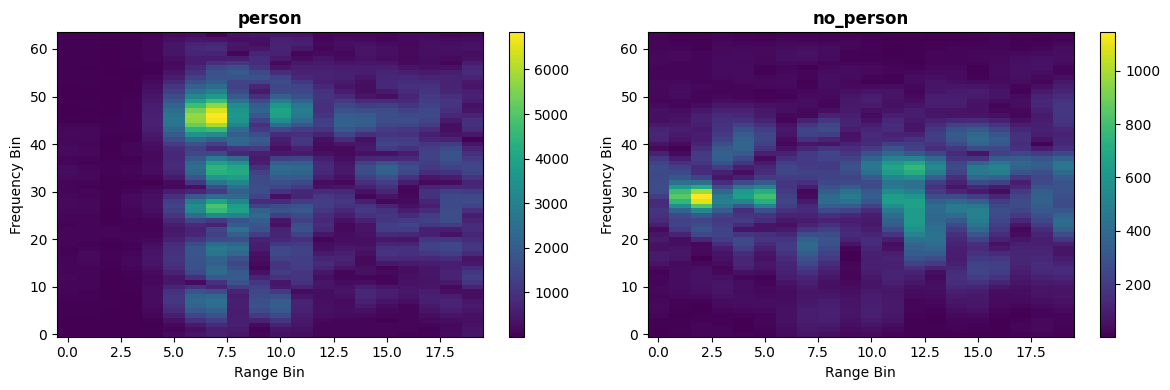

In [6]:
if len(X) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for class_idx in range(2):
        sample_idx = np.where(y == class_idx)[0][0]
        im = axes[class_idx].imshow(X[sample_idx], aspect='auto', cmap='viridis', origin='lower')
        axes[class_idx].set_title(f'{CLASSES[class_idx]}', fontsize=12, fontweight='bold')
        axes[class_idx].set_xlabel('Range Bin')
        axes[class_idx].set_ylabel('Frequency Bin')
        plt.colorbar(im, ax=axes[class_idx])

    plt.tight_layout()
    plt.show()

## 6. Data Split

In [7]:
if len(X) > 0:
    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=TEST_SPLIT, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=VALIDATION_SPLIT/(1-TEST_SPLIT), random_state=42, stratify=y_temp
    )

    # Add channel dimension
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 1867, Val: 575, Test: 432


## 7. Model Architecture

In [8]:
def build_model(input_shape, num_classes=2):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # first conv block
        layers.Conv2D(16, (2, 2), padding='same'),
        layers.MaxPooling2D((2, 2)),
        # second conv block
        layers.Conv2D(32, (2, 2), padding='same'),
        layers.MaxPooling2D((2, 2)),
        # Gap pool and dense layers
        layers.GlobalAveragePooling2D(),
        # layers.Dense(64, activation='relu'),
        # layers.Dropout(0.3),
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = build_model(X_train.shape[1:], num_classes=len(CLASSES))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 20, 16)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 10, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 5, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,226 (8.70 KB)

 Trainable params: 2,226 (8.70 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Training

In [9]:
if len(X) > 0:
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8259 - loss: 0.8085 - val_accuracy: 0.8383 - val_loss: 0.6854
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8254 - loss: 0.8077 - val_accuracy: 0.9687 - val_loss: 0.1245
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9395 - loss: 0.2468 - val_accuracy: 0.9757 - val_loss: 0.1130
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9057 - loss: 0.4301 - val_accuracy: 0.8870 - val_loss: 0.6632
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9384 - loss: 0.3015 - val_accuracy: 0.8748 - val_loss: 0.7986
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9480 - loss: 0.2551 - val_accuracy: 0.9217 - val_loss: 0.3975
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9507 - loss: 0.2354 - val_accuracy: 0.9270 - val_loss: 0.3707
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9507 - loss: 0.2376 - val_accuracy: 0.

## 9. Evaluation

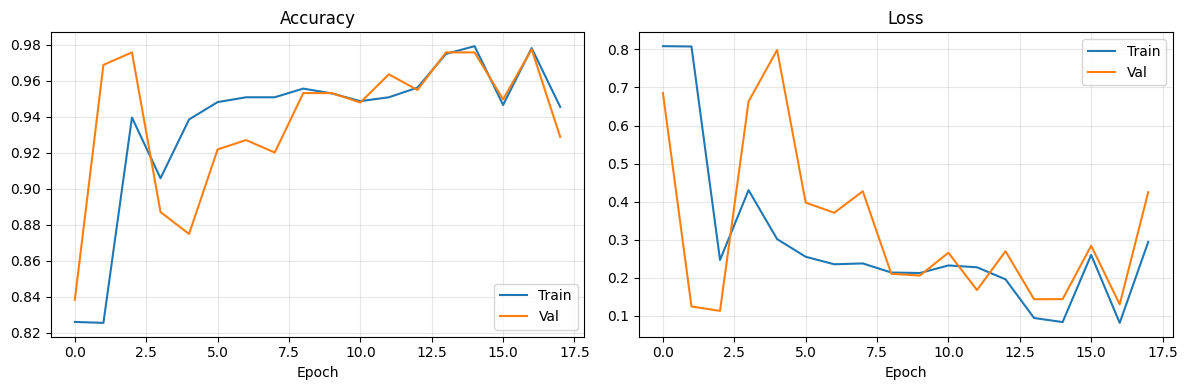


Test Accuracy: 0.9699

              precision    recall  f1-score   support

      person       0.98      0.96      0.97       216
   no_person       0.96      0.98      0.97       216

    accuracy                           0.97       432
   macro avg       0.97      0.97      0.97       432
weighted avg       0.97      0.97      0.97       432



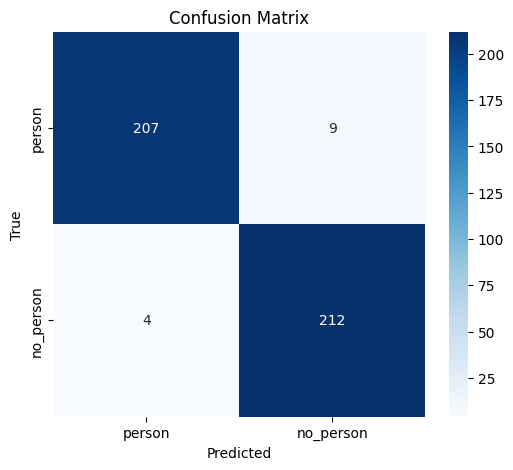

In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test metrics
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\n" + classification_report(y_test, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## 10. TensorFlow Lite - Full Integer Quantization

**Full Integer Quantization**: Converts both weights AND activations to int8.
- Advantages: Faster inference, lower memory, runs on integer-only hardware
- Requirements: Representative dataset for calibration

In [11]:

# Representative dataset for calibration
def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

# Convert with full integer quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_int8 = converter.convert()

with open('person_detection_int8.tflite', 'wb') as f:
    f.write(tflite_model_int8)

print(f"TFLite model (full int8): {len(tflite_model_int8)/1024:.2f} KB")

# Test int8 model
interpreter_int8 = tf.lite.Interpreter(model_content=tflite_model_int8)
interpreter_int8.allocate_tensors()

input_details_int8 = interpreter_int8.get_input_details()
output_details_int8 = interpreter_int8.get_output_details()

# Quantize input
input_scale, input_zero_point = input_details_int8[0]['quantization']
test_sample_quantized = (X_test[0:1] / input_scale + input_zero_point).astype(np.int8)

interpreter_int8.set_tensor(input_details_int8[0]['index'], test_sample_quantized)
interpreter_int8.invoke()
output_int8 = interpreter_int8.get_tensor(output_details_int8[0]['index'])

# Dequantize output
output_scale, output_zero_point = output_details_int8[0]['quantization']
output_float = (output_int8.astype(np.float32) - output_zero_point) * output_scale

print(f"INT8 Prediction: {CLASSES[np.argmax(output_float)]}, Confidence: {np.max(output_float):.4f}")

Saved artifact at '/tmp/tmpx82g0rwl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 20, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136502294062160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136502294068496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136502294065808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136502294068688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136502294064848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136502294068880: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model (full int8): 6.73 KB
INT8 Prediction: person, Confidence: 0.9961


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 11. TensorFlow Lite Micro - C Array Export

**TFLite Micro**: Optimized for microcontrollers (ESP32, Arduino, etc.)
- Converts .tflite to C/C++ byte array
- Can be included directly in embedded firmware
- No file system required on device

In [12]:
# MODEL_TFLITE = "person_detection_quantized.tflite"
MODEL_TFLITE = "person_detection_int8.tflite"
MODEL_TFLITE_MICRO = "model.h"

In [13]:
# Install xxd if it is not available
# !apt-get update && apt-get -qq install xxd
# Convert to a C source file, i.e, a TensorFlow Lite for Microcontrollers model
# !xxd -i {MODEL_TFLITE} > {MODEL_TFLITE_MICRO}
# Update variable names
# REPLACE_TEXT = MODEL_TFLITE.replace('/', '_').replace('.', '_')
# !sed -i 's/'{REPLACE_TEXT}'/g_model/g' {MODEL_TFLITE_MICRO}

In [14]:
def convert_to_c_array(data, var_name='g_model'):
    c_str = f'alignas(8) const unsigned char {var_name}[] = {{\n'

    hex_array = [f'0x{b:02x}' for b in data]
    for i in range(0, len(hex_array), 12):
        c_str += '  ' + ', '.join(hex_array[i:i+12]) + ',\n'

    c_str += '};\n\n'
    c_str += f'const int {var_name}_len = {len(data)};\n'
    return c_str

# Generate model.cpp
cpp_code = convert_to_c_array(tflite_model_int8, 'g_model')

with open('model.h', 'w') as f:
    f.write(cpp_code)